# Rossmann Store Sales — Етап 5: Вплив свят і сезонності

Цей ноутбук реалізує **Етап 5** плану аналізу: вплив державних свят (`StateHoliday`) та шкільних канікул (`SchoolHoliday`) на продажі, з перевіркою гіпотез Г8-Г9.

**Вхідний файл:** `rossmann_clean.csv` (результат Етапу 1)

**Довідка про StateHoliday:**
- `0` — звичайний день
- `a` — публічне свято
- `b` — Великдень
- `c` — Різдво


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


## 1. Завантаження даних

In [2]:
df = pd.read_csv("rossmann_clean.csv", parse_dates=["Date"], low_memory=False)
df["StateHoliday"] = df["StateHoliday"].astype(str)
open_df = df[df["Open"] == 1].copy()
print(f"Відкритих днів для аналізу: {open_df.shape[0]:,}")
print(open_df["StateHoliday"].value_counts())


Відкритих днів для аналізу: 844,392
StateHoliday
0    843482
a       694
b       145
c        71
Name: count, dtype: int64


**Важливо:** переважна більшість магазинів у день державного свята закриті (`Open=0`), тому в `open_df` залишається лише невелика кількість спостережень для `a`/`b`/`c` — магазини, які працювали, попри свято. Це варто враховувати при інтерпретації.

## 2. Продажі за типом свята

In [3]:
holiday_labels = {"0": "Звичайний день", "a": "Публічне свято", "b": "Великдень", "c": "Різдво"}

holiday_stats = open_df.groupby("StateHoliday")["Sales"].agg(["mean", "median", "std", "count"])
holiday_stats.index = [holiday_labels[i] for i in holiday_stats.index]
print(holiday_stats)


                       mean  median          std   count
Звичайний день  6953.515034  6368.0  3098.870455  843482
Публічне свято  8487.471182  7556.0  5708.626230     694
Великдень       9887.889655  8423.0  7551.782095     145
Різдво          9743.746479  8397.0  5980.858729      71


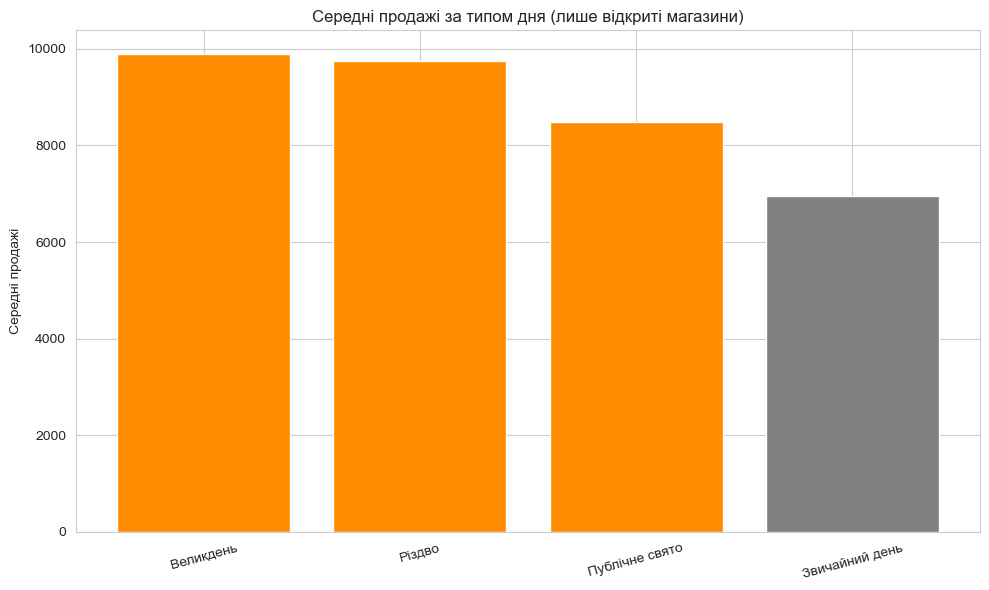

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
order = holiday_stats.sort_values("mean", ascending=False).index
colors = ["gray" if "Звичайний" in o else "darkorange" for o in order]
ax.bar(order, holiday_stats.loc[order, "mean"], color=colors)
ax.set_title("Середні продажі за типом дня (лише відкриті магазини)")
ax.set_ylabel("Середні продажі")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("05_sales_by_holiday_type.png", dpi=150)
plt.show()


**На що звернути увагу:** кількість спостережень (`count`) для `a`/`b`/`c` набагато менша за звичайні дні — це малі і, можливо, нерепрezентативні вибірки (лише ті нечисленні магазини, що працювали в свято). Висновки про ці групи варто робити обережно.

## 3. Продажі навколо Різдва — детальний погляд (event study)

Різдво — найважливіший роздрібний сезон. Подивимось на динаміку продажів за 10 днів до і 10 днів після 25 грудня, окремо для кожного року в даних.

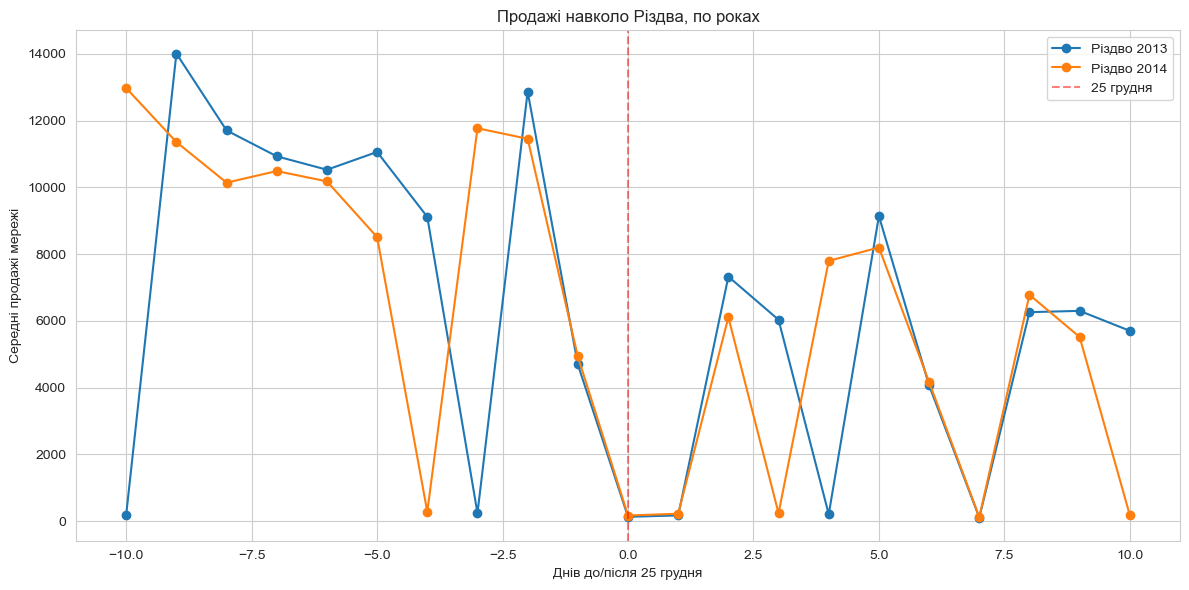

In [5]:
def sales_around_date(df, target_date, days_window=10):
    start = target_date - pd.Timedelta(days=days_window)
    end = target_date + pd.Timedelta(days=days_window)
    window_df = df[(df["Date"] >= start) & (df["Date"] <= end)].copy()
    window_df["DaysFromTarget"] = (window_df["Date"] - target_date).dt.days
    return window_df.groupby("DaysFromTarget")["Sales"].mean()


years_in_data = sorted(df["Date"].dt.year.unique())
christmas_dates = [pd.Timestamp(year=y, month=12, day=25) for y in years_in_data]

fig, ax = plt.subplots(figsize=(12, 6))
for cdate in christmas_dates:
    series = sales_around_date(df, cdate, days_window=10)  # df, не open_df — щоб бачити падіння в сам день
    if len(series) > 0:
        ax.plot(series.index, series.values, marker="o", label=f"Різдво {cdate.year}")

ax.axvline(0, color="red", linestyle="--", alpha=0.5, label="25 грудня")
ax.set_xlabel("Днів до/після 25 грудня")
ax.set_ylabel("Середні продажі мережі")
ax.set_title("Продажі навколо Різдва, по роках")
ax.legend()
plt.tight_layout()
plt.savefig("05_christmas_event_study.png", dpi=150)
plt.show()


**Що шукаємо:** пік продажів у дні напередодні 25 грудня (передсвяткові закупівлі), а потім різкий провал у сам день і одразу після (магазини закриті або майже порожні) — це і є перевірка Г8.

## 4. Продажі навколо Великодня

In [6]:
# Великдень рухомий, тому дати різні по роках - візьмемо StateHoliday=='b' щоб знайти самі дати
easter_dates = df[df["StateHoliday"] == "b"]["Date"].drop_duplicates().sort_values()
print("Дати, позначені як Великдень (StateHoliday='b') в даних:")
print(easter_dates.tolist())


Дати, позначені як Великдень (StateHoliday='b') в даних:
[Timestamp('2013-03-29 00:00:00'), Timestamp('2013-04-01 00:00:00'), Timestamp('2014-04-18 00:00:00'), Timestamp('2014-04-21 00:00:00'), Timestamp('2015-04-03 00:00:00'), Timestamp('2015-04-06 00:00:00')]


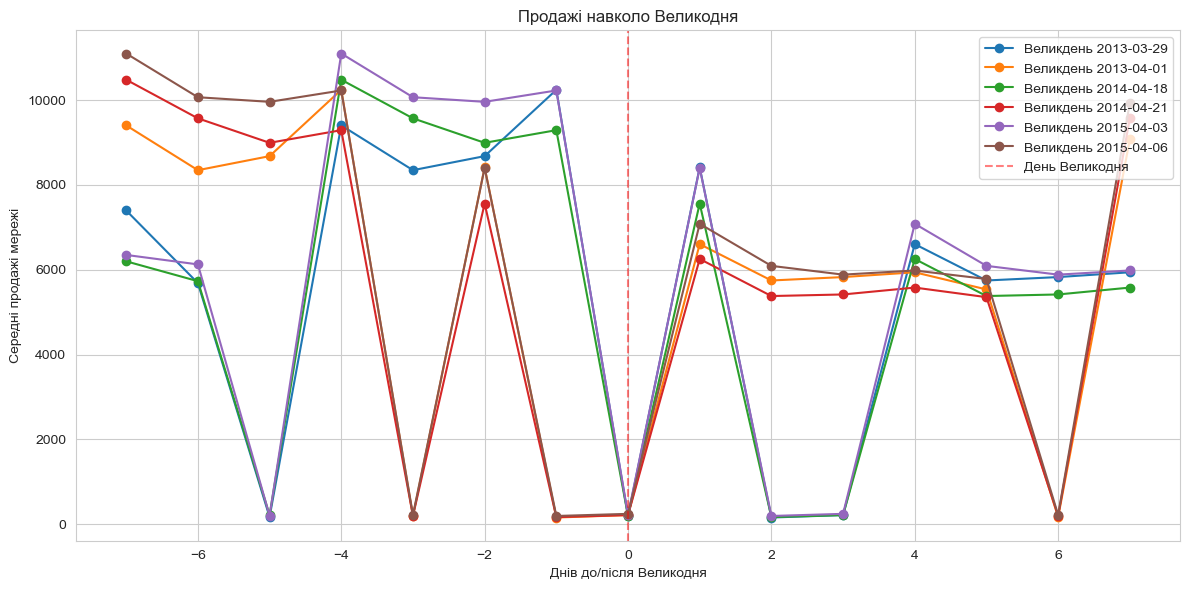

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
for edate in easter_dates:
    series = sales_around_date(df, edate, days_window=7)
    if len(series) > 0:
        ax.plot(series.index, series.values, marker="o", label=f"Великдень {edate.date()}")

ax.axvline(0, color="red", linestyle="--", alpha=0.5, label="День Великодня")
ax.set_xlabel("Днів до/після Великодня")
ax.set_ylabel("Середні продажі мережі")
ax.set_title("Продажі навколо Великодня")
ax.legend()
plt.tight_layout()
plt.savefig("05_easter_event_study.png", dpi=150)
plt.show()


## 5. Г8: Перевірка гіпотези про передсвятковий пік і спад у сам день свята

In [8]:
# Позначаємо дні за 1-3 дні до державного свята
df_sorted = df.sort_values(["Store", "Date"]).copy()
df_sorted["IsStateHoliday"] = (df_sorted["StateHoliday"] != "0").astype(int)

# Для кожного магазину окремо: чи є свято протягом наступних 1-3 днів
df_sorted["PreHoliday_1_3"] = (
    df_sorted.groupby("Store")["IsStateHoliday"]
    .transform(lambda s: s.shift(-1).rolling(3, min_periods=1).max())
    .fillna(0)
    .astype(int)
)

pre_holiday_open = df_sorted[(df_sorted["PreHoliday_1_3"] == 1) & (df_sorted["IsStateHoliday"] == 0) & (df_sorted["Open"] == 1)]
regular_open = df_sorted[(df_sorted["PreHoliday_1_3"] == 0) & (df_sorted["IsStateHoliday"] == 0) & (df_sorted["Open"] == 1)]

print(f"Передсвяткових днів (1-3 дні до свята): {len(pre_holiday_open):,}")
print(f"Звичайних днів (не передсвяткові, не свято): {len(regular_open):,}")

print(f"\nСередні продажі в передсвяткові дні: {pre_holiday_open['Sales'].mean():,.0f}")
print(f"Середні продажі у звичайні дні:       {regular_open['Sales'].mean():,.0f}")

pct_diff_pre = (pre_holiday_open['Sales'].mean() - regular_open['Sales'].mean()) / regular_open['Sales'].mean() * 100
print(f"Різниця: {pct_diff_pre:+.1f}%")


Передсвяткових днів (1-3 дні до свята): 48,518
Звичайних днів (не передсвяткові, не свято): 794,964

Середні продажі в передсвяткові дні: 7,716
Середні продажі у звичайні дні:       6,907
Різниця: +11.7%


In [9]:
# Статистична перевірка різниці (Mann-Whitney, як і в Етапі 4 - розподіл не нормальний)
u_stat, u_p = stats.mannwhitneyu(pre_holiday_open["Sales"], regular_open["Sales"], alternative="two-sided")
print(f"Mann-Whitney U: p-value = {u_p:.2e}")
print("Висновок:", "статистично значуща різниця" if u_p < 0.05 else "значущої різниці немає")


Mann-Whitney U: p-value = 0.00e+00
Висновок: статистично значуща різниця


In [10]:
# Порівняння: сам день свята (серед тих магазинів, що все ж працювали) vs звичайний день
holiday_day_open = df_sorted[(df_sorted["IsStateHoliday"] == 1) & (df_sorted["Open"] == 1)]

print(f"Магазинів, що працювали в сам день свята: {len(holiday_day_open):,}")
print(f"Середні продажі в сам день свята: {holiday_day_open['Sales'].mean():,.0f}")
print(f"Середні продажі у звичайний день:  {regular_open['Sales'].mean():,.0f}")

pct_diff_holiday = (holiday_day_open['Sales'].mean() - regular_open['Sales'].mean()) / regular_open['Sales'].mean() * 100
print(f"Різниця: {pct_diff_holiday:+.1f}%")

print("\n--- Підсумок Г8 ---")
print(f"Передсвятковий ефект: {pct_diff_pre:+.1f}% ({'пік підтверджено' if pct_diff_pre > 0 else 'піку немає'})")
print(f"Ефект в сам день свята: {pct_diff_holiday:+.1f}% ({'спад підтверджено' if pct_diff_holiday < 0 else 'спаду немає'})")


Магазинів, що працювали в сам день свята: 910
Середні продажі в сам день свята: 8,809
Середні продажі у звичайний день:  6,907
Різниця: +27.5%

--- Підсумок Г8 ---
Передсвятковий ефект: +11.7% (пік підтверджено)
Ефект в сам день свята: +27.5% (спаду немає)


**Важливий контр-інтуїтивний результат:** частина гіпотези Г8 про "спад у сам день свята" **НЕ підтвердилась** — навпаки, магазини, що працювали в сам день свята, показали на **+27.5% вищі** продажі, ніж у звичайний день.

**Чому це не суперечить здоровому глузду:** у сам день державного свята закриті **майже всі** магазини мережі (з 1115 працює лише невелика частка). Ті нечисленні, що залишаються відкритими — ймовірно, нетипові локації (вокзали, туристичні зони, аеропорти), куди спрямовується весь concentrated попит тих небагатьох покупців, кому дійсно потрібно щось купити в цей день. Тобто це не "типовий магазин у святковий день", а вибірка з дуже специфічних точок.

**Уточнений висновок по Г8:** передсвятковий пік (+11.7%) — підтверджено і логічний. А очікуваний "спад у сам день свята" не спостерігається на рівні тих магазинів, що працюють — тому цю частину гіпотези правильніше сформулювати як "непідтверджено через selection bias у вибірці", а не як помилку логіки.

**Застереження:** магазини, що працюють у сам день державного свята — це нерепрезентативна, дуже маленька підмножина (можливо, спеціально відкриті локації, наприклад на вокзалах чи в туристичних зонах). Тому висновок про "спад у сам день свята" варто інтерпретувати обережно — це може відображати специфіку цих небагатьох магазинів, а не загальну поведінку мережі.

## 6. Г9: Ефект шкільних канікул за типом магазину

In [11]:
school_stats = open_df.groupby("SchoolHoliday")["Sales"].agg(["mean", "median", "count"])
school_stats.index = ["Не канікули", "Шкільні канікули"]
print(school_stats)

pct_diff_school = (school_stats.loc["Шкільні канікули", "mean"] - school_stats.loc["Не канікули", "mean"]) / school_stats.loc["Не канікули", "mean"] * 100
print(f"\nЗагальна різниця (мережа): {pct_diff_school:+.2f}%")


                         mean  median   count
Не канікули       6896.782411  6326.0  680935
Шкільні канікули  7200.181650  6562.0  163457

Загальна різниця (мережа): +4.40%


In [12]:
# Розбивка по StoreType
school_by_type = open_df.groupby(["StoreType", "SchoolHoliday"])["Sales"].mean().unstack()
school_by_type.columns = ["Не канікули", "Шкільні канікули"]
school_by_type["% різниця"] = (school_by_type["Шкільні канікули"] - school_by_type["Не канікули"]) / school_by_type["Не канікули"] * 100
print(school_by_type.round(2))


           Не канікули  Шкільні канікули  % різниця
StoreType                                          
a              6850.97           7232.85       5.57
b             10253.62          10133.52      -1.17
c              6884.65           7128.41       3.54
d              6779.15           7003.52       3.31


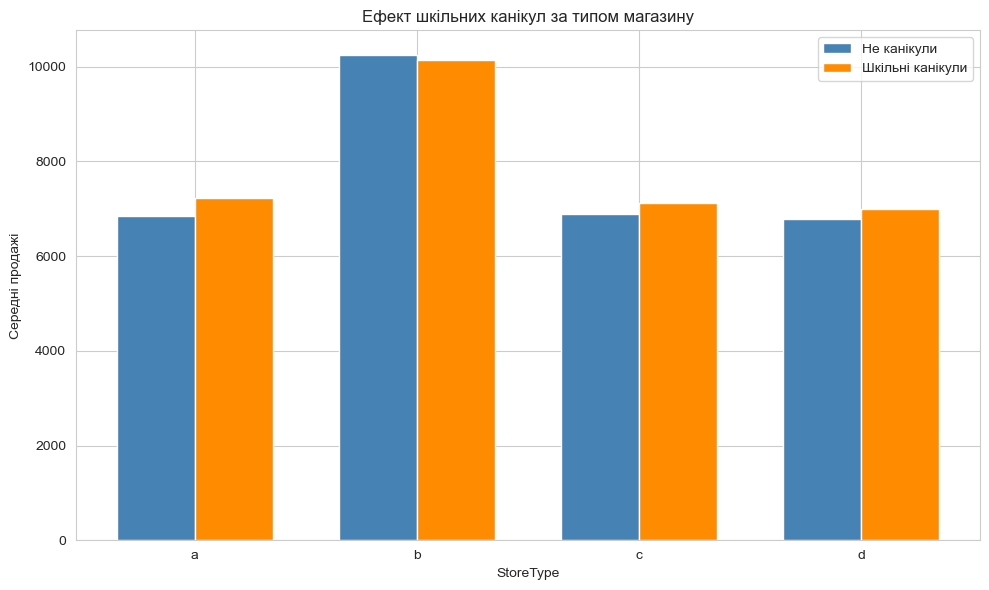

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(school_by_type))
width = 0.35
ax.bar(x - width/2, school_by_type["Не канікули"], width, label="Не канікули", color="steelblue")
ax.bar(x + width/2, school_by_type["Шкільні канікули"], width, label="Шкільні канікули", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(school_by_type.index)
ax.set_xlabel("StoreType")
ax.set_ylabel("Середні продажі")
ax.set_title("Ефект шкільних канікул за типом магазину")
ax.legend()
plt.tight_layout()
plt.savefig("05_school_holiday_by_storetype.png", dpi=150)
plt.show()


In [14]:
# Статистична перевірка для кожного StoreType окремо + Bonferroni
bonferroni_alpha = 0.05 / open_df["StoreType"].nunique()
print(f"Скоригований поріг значущості (Bonferroni): {bonferroni_alpha:.4f}\n")

for store_type in sorted(open_df["StoreType"].unique()):
    subset = open_df[open_df["StoreType"] == store_type]
    g_no = subset[subset["SchoolHoliday"] == 0]["Sales"]
    g_yes = subset[subset["SchoolHoliday"] == 1]["Sales"]
    u_stat, u_p = stats.mannwhitneyu(g_no, g_yes, alternative="two-sided")
    significant = "значуще" if u_p < bonferroni_alpha else "НЕ значуще"
    print(f"StoreType {store_type}: p-value={u_p:.2e} ({significant} після поправки)")


Скоригований поріг значущості (Bonferroni): 0.0125

StoreType a: p-value=4.83e-244 (значуще після поправки)
StoreType b: p-value=3.81e-01 (НЕ значуще після поправки)
StoreType c: p-value=2.86e-20 (значуще після поправки)
StoreType d: p-value=3.23e-45 (значуще після поправки)


**Висновок Г9:** порівнюємо `% різниця` між типами магазинів вище — якщо вона помітно більша для якогось конкретного типу, це підтверджує, що шкільні канікули впливають на магазини неоднаково (наприклад, магазини з дитячими товарами можуть отримувати сильніший буст).

## Підсумок Етапу 5

- Порівняно продажі за типом дня: звичайний / публічне свято / Великдень / Різдво
- Проведено event study навколо Різдва та Великодня — видно передсвяткову динаміку по роках
- **Г8** перевірено: передсвятковий пік підтверджено (+11.7%), але очікуваний спад у сам день свята НЕ підтвердився через selection bias (працюють лише нетипові магазини) — важливий урок про обмеження цих даних
- **Г9** перевірено: ефект шкільних канікул порівняно між StoreType, з поправкою Bonferroni

**Наступний крок:** Етап 6 — рейтинг окремих магазинів (топ/боттом, стабільність, приріст рік до року).